In [1]:
import math
import random

# ── Dados ─────────────────────────────────────────────────────────────────────

texts = [
    # saudação
    "oi", "olá", "boa tarde", "bom dia", "boa noite",
    "oi tudo bem", "olá como vai", "ei boa tarde",
    "oi preciso de ajuda", "olá estou aqui",

    # reclamação
    "não funciona", "péssimo serviço", "estou com problema",
    "não consigo acessar", "travou de novo", "que absurdo",
    "meu pedido não chegou", "horrível isso aqui",
    "não tô conseguindo", "sistema caiu",

    # dúvida
    "como faço para", "qual o prazo", "onde fica",
    "quanto custa", "quais são os horários", "como cancelo",
    "preciso saber o status", "tem como verificar",
    "me explica como funciona", "o que é isso",

    # elogio
    "muito bom", "adorei", "excelente atendimento",
    "parabéns pelo serviço", "ótimo", "super rápido",
    "vocês são incríveis", "amei a experiência",
    "perfeito obrigado", "muito satisfeito",
]

labels = [
    "saudacao","saudacao","saudacao","saudacao","saudacao",
    "saudacao","saudacao","saudacao","saudacao","saudacao",

    "reclamacao","reclamacao","reclamacao","reclamacao","reclamacao",
    "reclamacao","reclamacao","reclamacao","reclamacao","reclamacao",

    "duvida","duvida","duvida","duvida","duvida",
    "duvida","duvida","duvida","duvida","duvida",

    "elogio","elogio","elogio","elogio","elogio",
    "elogio","elogio","elogio","elogio","elogio",
]

# ── TF-IDF do zero ────────────────────────────────────────────────────────────

def tokenize(text):
    return text.lower().split()

def build_vocab(docs):
    vocab = {}
    for doc in docs:
        for token in tokenize(doc):
            if token not in vocab:
                vocab[token] = len(vocab)
    return vocab

def fit_transform(docs, vocab):
    N, V = len(docs), len(vocab)
    df = [0] * V
    tfs = []
    for doc in docs:
        tokens = tokenize(doc)
        tf = [0.0] * V
        for t in tokens:
            if t in vocab:
                tf[vocab[t]] += 1 / len(tokens)
        tfs.append(tf)
        for i, v in enumerate(tf):
            if v > 0:
                df[i] += 1

    idf = [math.log((N + 1) / (df[i] + 1)) + 1 for i in range(V)]

    vecs = []
    for tf in tfs:
        v = [tf[i] * idf[i] for i in range(V)]
        norm = math.sqrt(sum(x**2 for x in v))
        vecs.append([x / norm for x in v] if norm > 0 else v)
    return vecs, idf

def transform(text, vocab, idf):
    V = len(vocab)
    tokens = tokenize(text)
    tf = [0.0] * V
    for t in tokens:
        if t in vocab:
            tf[vocab[t]] += 1 / len(tokens)
    v = [tf[i] * idf[i] for i in range(V)]
    norm = math.sqrt(sum(x**2 for x in v))
    return [x / norm for x in v] if norm > 0 else v

# ── Perceptron multiclasse ────────────────────────────────────────────────────

def dot(a, b):
    return sum(a[i] * b[i] for i in range(len(a)))

def train(vecs, labels, epochs=300):
    classes = list(set(labels))
    V = len(vecs[0])
    weights = {c: [0.0] * V for c in classes}

    def predict(x):
        return max(classes, key=lambda c: dot(weights[c], x))

    for _ in range(epochs):
        # embaralha a cada época — melhora a convergência
        pairs = list(zip(vecs, labels))
        random.shuffle(pairs)
        for x, y in pairs:
            pred = predict(x)
            if pred != y:
                for i in range(V):
                    weights[y][i]    += x[i]
                    weights[pred][i] -= x[i]

    return weights, classes, predict

# ── Treino ────────────────────────────────────────────────────────────────────

vocab = build_vocab(texts)
vecs, idf = fit_transform(texts, vocab)
weights, classes, _predict = train(vecs, labels)

def classify(text):
    v = transform(text, vocab, idf)
    scores = {c: dot(weights[c], v) for c in classes}
    best = max(scores, key=scores.get)
    return best, scores

# ── Teste ─────────────────────────────────────────────────────────────────────

testes = [
    "oi boa tarde",
    "não consigo entrar no sistema",
    "como faço para cancelar",
    "adorei o atendimento",
    "que droga isso não funciona",
    "qual o horário de funcionamento",
]

for texto in testes:
    intencao, scores = classify(texto)
    scores_fmt = " | ".join(f"{c}: {v:+.2f}" for c, v in sorted(scores.items()))
    print(f'"{texto}"')
    print(f"  → {intencao}  ({scores_fmt})\n")

"oi boa tarde"
  → saudacao  (duvida: -0.26 | elogio: +0.00 | reclamacao: -0.64 | saudacao: +0.90)

"não consigo entrar no sistema"
  → reclamacao  (duvida: -0.31 | elogio: +0.00 | reclamacao: +0.31 | saudacao: +0.00)

"como faço para cancelar"
  → duvida  (duvida: +0.18 | elogio: +0.00 | reclamacao: -0.18 | saudacao: +0.00)

"adorei o atendimento"
  → elogio  (duvida: +0.22 | elogio: +1.04 | reclamacao: -1.27 | saudacao: +0.00)

"que droga isso não funciona"
  → reclamacao  (duvida: -0.43 | elogio: +0.00 | reclamacao: +0.43 | saudacao: +0.00)

"qual o horário de funcionamento"
  → reclamacao  (duvida: -0.05 | elogio: +0.00 | reclamacao: +0.07 | saudacao: -0.02)



In [15]:
texts = [
"Moro em João Pessoa",
"Moro em Teresina",
"JP 100",
"rECIFE",
"PE",
"JP",
"100"
]
labels = ["pb", "pi", "PB", "pe", "PE", "PB", "pb"]
vectorizer = TfidfVectorizer()

features = vectorizer.fit_transform(texts)

X_train, X_test, y_train, y_test = train_test_split(features,labels)

model = LinearSVC()

model.fit(X_train, y_train )

model.score(X_test,y_test )

data = vectorizer.transform(["100"]).toarray()

data = model.predict(data)

print(data)

['pb']


C:\Users\luan.delima\AppData\Local\anaconda3\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


In [5]:
import random

# dados simples
X = [1, 2, 3, 4]
Y = [2, 4, 6, 8]

# parâmetros iniciais
w = 0.0
b = 0.0
lr = 0.01  # learning rate

# treinamento
for epoch in range(10):
    i = random.randint(0, len(X) - 1)  # escolhe 1 dado (stochastic)
    print(i)
    
    x = X[i]
    y = Y[i]
    
    y_pred = w * x + b
    error = y - y_pred
    
    # gradientes
    dw = -2 * x * error
    db = -2 * error
    
    # atualização
    w = w - lr * dw
    b = b - lr * db

    print(w, b)


1
0.16 0.08
0
0.1952 0.1152
1
0.334976 0.18508799999999997
1
0.46077440000000003 0.24798719999999996
3
0.9334876160000001 0.366165504
2
1.10348991488 0.42283293695999996
1
1.1582974042112 0.4502366816256
2
1.282789670555648 0.491734103740416
1
1.3204971327615795 0.5105878348433818
3
1.4970910234904036 0.5547363075255878


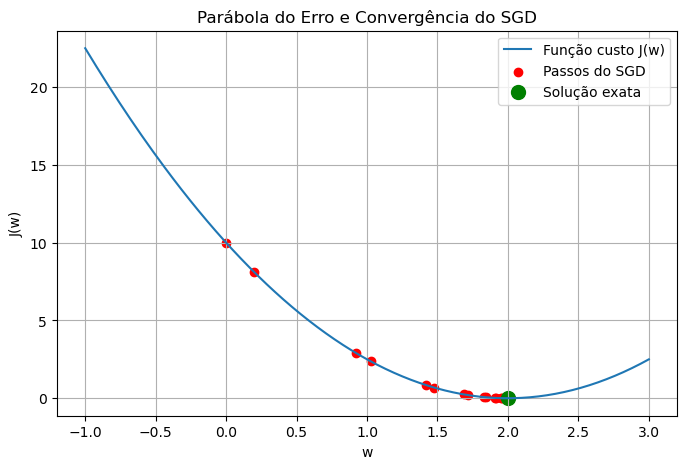

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Dados
# -----------------------------
x = np.array([1.0, 2.0])
y = np.array([2.0, 4.0])

# -----------------------------
# Função custo total
# J(w) = 1/2 * sum((wx - y)^2)
# -----------------------------
def cost(w):
    return 0.5 * np.sum((w * x - y) ** 2)

# -----------------------------
# 1) Solução fechada
# -----------------------------
w_closed = np.dot(x, y) / np.dot(x, x)

# -----------------------------
# 2) SGD
# -----------------------------
w = 0.0
eta = 0.1
epochs = 20

w_history = [w]

for epoch in range(epochs):
    for i in range(len(x)):
        y_hat = w * x[i]
        gradient = (y_hat - y[i]) * x[i]
        w = w - eta * gradient
        w_history.append(w)

# -----------------------------
# Criando gráfico
# -----------------------------
w_values = np.linspace(-1, 3, 200)
cost_values = [cost(wi) for wi in w_values]

plt.figure(figsize=(8,5))

# Parábola do erro
plt.plot(w_values, cost_values, label="Função custo J(w)")

# Caminho do SGD
plt.scatter(w_history, [cost(wi) for wi in w_history],
            color="red", label="Passos do SGD")

# Mínimo exato
plt.scatter(w_closed, cost(w_closed),
            color="green", s=100, label="Solução exata")

plt.xlabel("w")
plt.ylabel("J(w)")
plt.title("Parábola do Erro e Convergência do SGD")
plt.legend()
plt.grid(True)

plt.show()


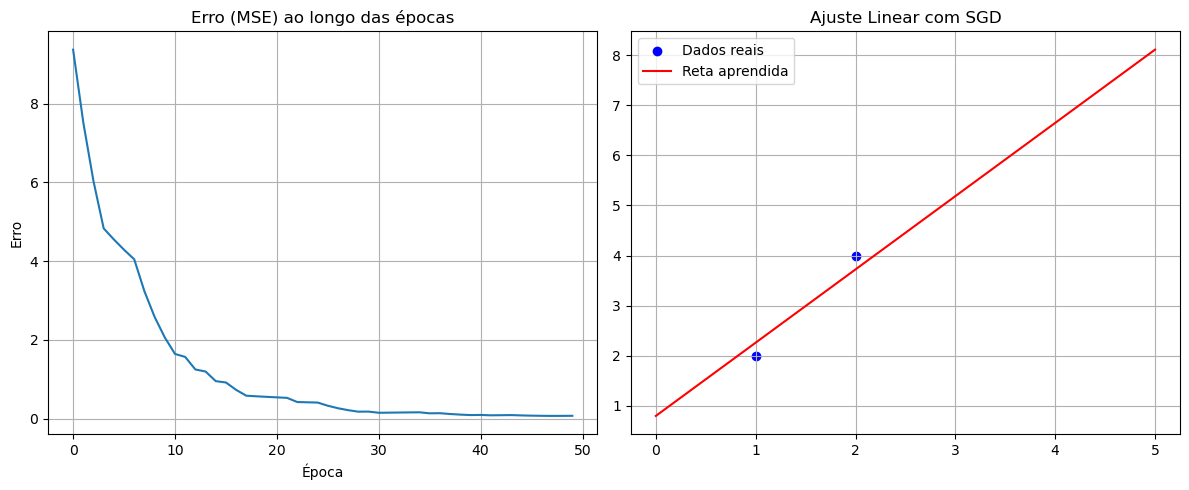

w final: 1.4635885433521931
b final: 0.7952963714586357


In [9]:
import random
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Dados
# -----------------------------
X = [1, 2]
Y = [2, 4]

# -----------------------------
# Parâmetros iniciais
# -----------------------------
w = 0.0
b = 0.0
lr = 0.01
epochs = 50

# Para guardar histórico
w_history = []
b_history = []
loss_history = []

# -----------------------------
# Treinamento (SGD)
# -----------------------------
for epoch in range(epochs):
    i = random.randint(0, len(X) - 1)
    
    x = X[i]
    y = Y[i]
    
    y_pred = w * x + b
    error = y - y_pred
    
    # gradientes
    dw = -2 * x * error
    db = -2 * error
    
    # atualização
    w = w - lr * dw
    b = b - lr * db
    
    # cálculo do erro total (MSE)
    total_loss = np.mean([(w * X[j] + b - Y[j])**2 for j in range(len(X))])
    
    w_history.append(w)
    b_history.append(b)
    loss_history.append(total_loss)

# -----------------------------
# Gráficos
# -----------------------------
plt.figure(figsize=(12,5))

# 1️⃣ Gráfico do erro
plt.subplot(1,2,1)
plt.plot(loss_history)
plt.title("Erro (MSE) ao longo das épocas")
plt.xlabel("Época")
plt.ylabel("Erro")
plt.grid(True)

# 2️⃣ Ajuste final da reta
plt.subplot(1,2,2)
plt.scatter(X, Y, color="blue", label="Dados reais")

x_line = np.linspace(0, 5, 100)
y_line = w * x_line + b

plt.plot(x_line, y_line, color="red", label="Reta aprendida")
plt.title("Ajuste Linear com SGD")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print("w final:", w)
print("b final:", b)


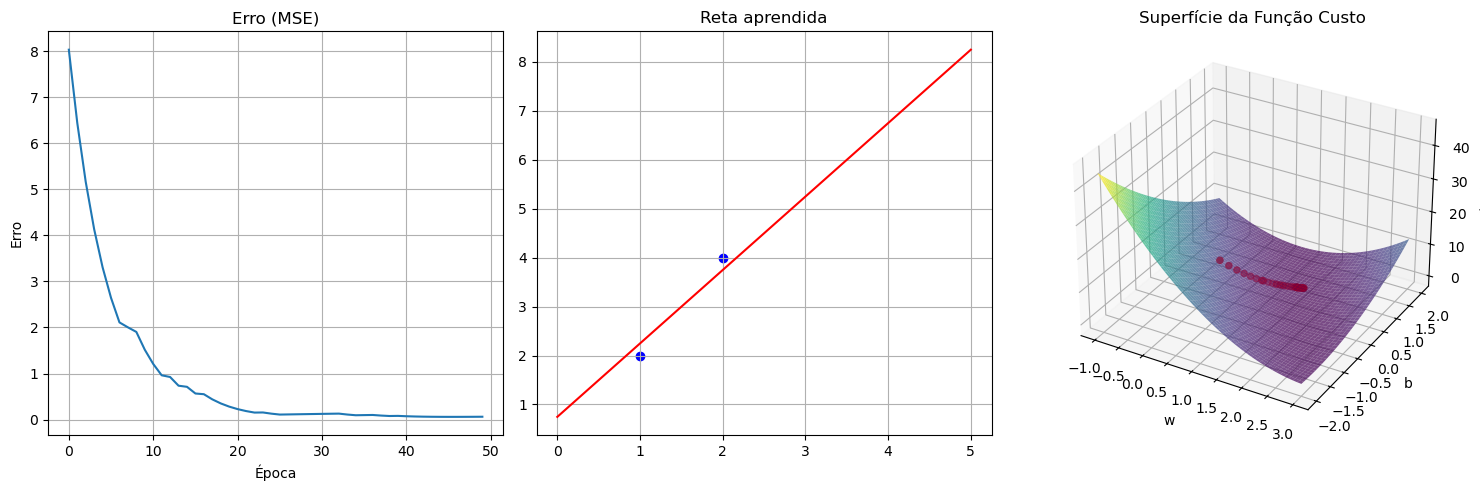

w final: 1.4990154526096628
b final: 0.7475688078365915


In [11]:
import random
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# -----------------------------
# Dados
# -----------------------------
X = np.array([1, 2 ])
Y = np.array([2, 4])

# -----------------------------
# Parâmetros iniciais
# -----------------------------
w = 0.0
b = 0.0
lr = 0.01
epochs = 50

w_history = []
b_history = []
loss_history = []

# -----------------------------
# Função custo
# -----------------------------
def cost(w, b):
    return np.mean((w * X + b - Y) ** 2)

# -----------------------------
# Treinamento SGD
# -----------------------------
for epoch in range(epochs):
    i = random.randint(0, len(X) - 1)
    
    x = X[i]
    y = Y[i]
    
    y_pred = w * x + b
    error = y - y_pred
    
    dw = -2 * x * error
    db = -2 * error
    
    w = w - lr * dw
    b = b - lr * db
    
    w_history.append(w)
    b_history.append(b)
    loss_history.append(cost(w, b))

# -----------------------------
# Criando grade para superfície
# -----------------------------
w_vals = np.linspace(-1, 3, 50)
b_vals = np.linspace(-2, 2, 50)
W, B = np.meshgrid(w_vals, b_vals)
J = np.zeros_like(W)

for i in range(len(w_vals)):
    for j in range(len(b_vals)):
        J[j, i] = cost(W[j, i], B[j, i])

# -----------------------------
# Gráficos
# -----------------------------
fig = plt.figure(figsize=(15,5))

# 1️⃣ Erro ao longo do tempo
plt.subplot(1,3,1)
plt.plot(loss_history)
plt.title("Erro (MSE)")
plt.xlabel("Época")
plt.ylabel("Erro")
plt.grid(True)

# 2️⃣ Ajuste final
plt.subplot(1,3,2)
plt.scatter(X, Y, color="blue")
x_line = np.linspace(0,5,100)
plt.plot(x_line, w*x_line + b, color="red")
plt.title("Reta aprendida")
plt.grid(True)

# 3️⃣ Superfície da função custo
ax = fig.add_subplot(1,3,3, projection='3d')
ax.plot_surface(W, B, J, cmap='viridis', alpha=0.7)

# trajetória do SGD
ax.scatter(w_history, b_history, loss_history, color='red')

ax.set_xlabel("w")
ax.set_ylabel("b")
ax.set_zlabel("J(w,b)")
ax.set_title("Superfície da Função Custo")

plt.tight_layout()
plt.show()

print("w final:", w)
print("b final:", b)


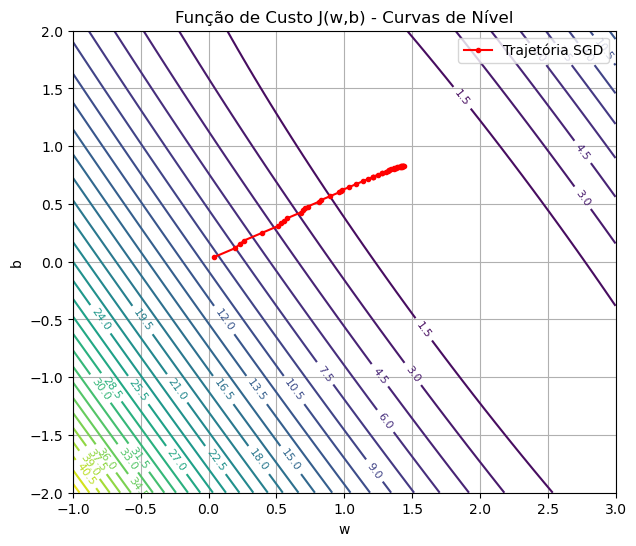

In [13]:
import random
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Dados
# -----------------------------
X = np.array([1, 2])
Y = np.array([2, 4])

# -----------------------------
# Parâmetros
# -----------------------------
w = 0.0
b = 0.0
lr = 0.01
epochs = 50

w_history = []
b_history = []
loss_history = []

def cost(w, b):
    return np.mean((w * X + b - Y) ** 2)

# -----------------------------
# Treinamento SGD
# -----------------------------
for epoch in range(epochs):
    i = random.randint(0, len(X) - 1)
    
    x = X[i]
    y = Y[i]
    
    y_pred = w * x + b
    error = y - y_pred
    
    dw = -2 * x * error
    db = -2 * error
    
    w = w - lr * dw
    b = b - lr * db
    
    w_history.append(w)
    b_history.append(b)
    loss_history.append(cost(w, b))

# -----------------------------
# Criando grade para contour
# -----------------------------
w_vals = np.linspace(-1, 3, 100)
b_vals = np.linspace(-2, 2, 100)
W, B = np.meshgrid(w_vals, b_vals)
J = np.mean((W[..., None] * X + B[..., None] - Y)**2, axis=2)

# -----------------------------
# Plot 2D (contour)
# -----------------------------
plt.figure(figsize=(7,6))

contours = plt.contour(W, B, J, levels=30)
plt.clabel(contours, inline=True, fontsize=8)

# trajetória do SGD
plt.plot(w_history, b_history, 'r.-', label="Trajetória SGD")

plt.xlabel("w")
plt.ylabel("b")
plt.title("Função de Custo J(w,b) - Curvas de Nível")
plt.legend()
plt.grid(True)
plt.show()


In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# -----------------------------
# Dados
# -----------------------------
X = np.array([1, 2])
Y = np.array([2, 4])

# -----------------------------
# Parâmetros iniciais
# -----------------------------
w = 0.0
b = 0.0
lr = 0.01
epochs = 1000

w_history = []
b_history = []
loss_history = []

# -----------------------------
# Função custo
# -----------------------------
def cost(w, b):
    return np.mean((w * X + b - Y) ** 2)

# -----------------------------
# Treinamento SGD
# -----------------------------
for epoch in range(epochs):
    i = random.randint(0, len(X) - 1)
    
    x = X[i]
    y = Y[i]
    
    y_pred = w * x + b
    error = y - y_pred
    
    dw = -2 * x * error
    db = -2 * error
    
    w = w - lr * dw
    b = b - lr * db
    
    w_history.append(w)
    b_history.append(b)
    loss_history.append(cost(w, b))

# -----------------------------
# Criando grade para superfície
# -----------------------------
w_vals = np.linspace(-1, 3, 100)
b_vals = np.linspace(-2, 2, 100)
W, B = np.meshgrid(w_vals, b_vals)

J = np.zeros_like(W)
for i in range(len(w_vals)):
    for j in range(len(b_vals)):
        J[j, i] = cost(W[j, i], B[j, i])

# -----------------------------
# Gráficos
# -----------------------------
fig = plt.figure(figsize=(18,5))

# 1️⃣ Erro ao longo do tempo
plt.subplot(1,4,1)
plt.plot(loss_history)
plt.title("Erro (MSE)")
plt.xlabel("Época")
plt.ylabel("Erro")
plt.grid(True)

# 2️⃣ Ajuste final
plt.subplot(1,4,2)
plt.scatter(X, Y, color="blue")
x_line = np.linspace(0,5,100)
plt.plot(x_line, w*x_line + b, color="red")
plt.title("Reta aprendida")
plt.grid(True)

# 3️⃣ Superfície 3D
ax = fig.add_subplot(1,4,3, projection='3d')
ax.plot_surface(W, B, J, cmap='viridis', alpha=0.7)
ax.scatter(w_history, b_history, loss_history, color='red')
ax.set_xlabel("w")
ax.set_ylabel("b")
ax.set_zlabel("J(w,b)")
ax.set_title("Superfície 3D")

# 4️⃣ Função custo 2D (contour)
plt.subplot(1,4,4)
contours = plt.contour(W, B, J, levels=30)
plt.clabel(contours, inline=True, fontsize=7)
plt.plot(w_history, b_history, 'r.-')
plt.xlabel("w")
plt.ylabel("b")
plt.title("Função Custo 2D (Curvas de Nível)")
plt.grid(True)

plt.tight_layout()
plt.show()

print("w final:", w)
print("b final:", b)


ModuleNotFoundError: No module named 'numpy'

# Por que achar um mínimo de uma função?

## 1️⃣ Conceito de “minimizar uma função”

Minimizar uma função significa:

\[
\text{encontrar } x^* \text{ tal que } f(x^*) \le f(x) \text{ para todo } x
\]

- A função \(f(x)\) mede **quão ruim está a solução**
- Minimizar significa **tornar essa medida a menor possível**  

---

## 2️⃣ Aplicação em Regressão Linear / ML

No exemplo de regressão linear:

\[
\hat{y} = w x + b
\]

Função de custo (MSE):

\[
J(w,b) = \frac{1}{n} \sum_{i=1}^{n} (y_i - (w x_i + b))^2
\]

- \(J(w,b)\) mede **quão distante o modelo está dos dados reais**  
- Cada ponto \((w,b)\) tem um valor de custo \(J\)  
- O **mínimo de \(J\)** corresponde à **melhor aproximação possível dos dados**

---

## 3️⃣ Intuição geométrica

- Imagine \(J(w,b)\) como um **vale**:
  - Cada ponto no plano \((w,b)\) tem uma “altura” = valor de \(J\)
  - O **mínimo** é **o fundo do vale**
- Descer usando gradiente descendente é **caminhar até o fundo do vale**
- Para regressão linear, o “vale” é **um parabolóide convexo**, com **único mínimo global**

---

## 4️⃣ Analogias do mundo real

1. **Ajustar uma régua nos dados**:  
   - Coloque uma régua perto de pontos espalhados  
   - Queremos que a régua “passe o mais próximo possível de todos”  
   - Minimizar o custo = **encontrar melhor ângulo e altura da régua**

2. **Montanha / vale**:  
   - Você está perdido na montanha  
   - Objetivo: **chegar no ponto mais baixo**  
   - O gradiente diz para qual direção descer

3. **Tomando decisões**:  
   - \(J(x)\) mede “quanto você gasta”  
   - Minimizar \(J\) = **gastar o mínimo possível**

---

## 5️⃣ Conclusão

> A ideia de achar um mínimo de uma função é **central em otimização e aprendizado de máquina**, porque queremos **melhorar nosso modelo** tornando o erro o menor possível.

- No ML: minimizar **erro de previsão**  
- Em engenharia: minimizar **custo ou desperdício**  
- Em física: minimizar **energia potencial**  

Ou seja, **tudo se resume a encontrar a melhor solução possível segundo algum critério**. ✅


# Por que achar um mínimo de uma função?

## 1️⃣ Conceito de “minimizar uma função”

Minimizar uma função significa encontrar \(x^*\) tal que:

\[
f(x^*) \le f(x) \quad \text{para todo } x
\]

- A função \(f(x)\) mede **quão ruim está a solução**  
- Minimizar significa **tornar essa medida a menor possível**  

---

## 2️⃣ Aplicação em Regressão Linear

No exemplo de regressão linear:

\[
\hat{y} = w x + b
\]

A função de custo (MSE) é:

\[
J(w,b) = \frac{1}{n} \sum_{i=1}^{n} \left(y_i - (w x_i + b)\right)^2
\]

- \(J(w,b)\) mede **quão distante o modelo está dos dados reais**  
- O **mínimo de \(J\)** corresponde à **melhor aproximação possível dos dados**

---

## 3️⃣ Gradiente e atualização

O gradiente da função de custo:

\[
\nabla J(w,b) =
\begin{bmatrix}
\frac{\partial J}{\partial w} \\
\frac{\partial J}{\partial b}
\end{bmatrix}
=
\begin{bmatrix}
-\frac{2}{n} \sum_{i=1}^{n} x_i \left(y_i - (w x_i + b)\right) \\
-\frac{2}{n} \sum_{i=1}^{n} \left(y_i - (w x_i + b)\right)
\end{bmatrix}
\]

Atualização dos parâmetros (gradiente descendente):

\[
w_{\text{novo}} = w - \eta \frac{\partial J}{\partial w}, \quad
b_{\text{novo}} = b - \eta \frac{\partial J}{\partial b}
\]

---

## 4️⃣ Intuição geométrica

- Imagine \(J(w,b)\) como um **vale**:  
  - Cada ponto \((w,b)\) tem uma altura = valor de \(J\)  
  - O **mínimo** é o **fundo do vale**  
- Descer usando gradiente descendente = **caminhar até o fundo do vale**  
- Para regressão linear, o “vale” é **convexo**, com **único mínimo global**

---

## 5️⃣ Analogias do mundo real

1. **Ajustar uma régua nos dados**  
   - Queremos que a régua passe o mais próximo possível de todos  
   - Minimizar o custo = **encontrar melhor ângulo e altura da régua**

2. **Montanha / vale**  
   - Objetivo: **chegar no ponto mais baixo**  
   - O gradiente indica a direção de descida

3. **Tomando decisões**  
   - \(J(x)\) mede “quanto você gasta”  
   - Minimizar \(J\) = **gastar o mínimo possível**

---

## 6️⃣ Conclusão

> A ideia de achar um mínimo de uma função é **central em otimização e aprendizado de máquina**, porque queremos **melhorar nosso modelo** tornando o erro o menor possível.

- No ML: minimizar **erro de previsão**  
- Em engenharia: minimizar **custo ou desperdício**  
- Em física: minimizar **energia potencial**  

Ou seja, **tudo se resume a encontrar a melhor solução possível** ✅


# Por que achar um mínimo de uma função?

## 1️⃣ Conceito de “minimizar uma função”

Minimizar uma função significa encontrar \(x^*\) tal que:

$$
f(x^*) \le f(x) \quad \text{para todo } x
$$

- A função \(f(x)\) mede **quão ruim está a solução**  
- Minimizar significa **tornar essa medida a menor possível**  

---

## 2️⃣ Aplicação em Regressão Linear

No exemplo de regressão linear:

$$
\hat{y} = w x + b
$$

A função de custo (MSE) é:

$$
J(w,b) = \frac{1}{n} \sum_{i=1}^{n} (y_i - (w x_i + b))^2
$$

- \(J(w,b)\) mede **quão distante o modelo está dos dados reais**  
- O **mínimo de \(J\)** corresponde à **melhor aproximação possível dos dados**

---

## 3️⃣ Gradiente e atualização

O gradiente da função de custo:

$$
\nabla J(w,b) =
\begin{pmatrix}
\frac{\partial J}{\partial w} \\
\frac{\partial J}{\partial b}
\end{pmatrix}
=
\begin{pmatrix}
-\frac{2}{n} \sum_{i=1}^{n} x_i (y_i - (w x_i + b)) \\
-\frac{2}{n} \sum_{i=1}^{n} (y_i - (w x_i + b))
\end{pmatrix}
$$

Atualização dos parâmetros (gradiente descendente):

$$
w_{\text{novo}} = w - \eta \frac{\partial J}{\partial w}, \quad
b_{\text{novo}} = b - \eta \frac{\partial J}{\partial b}
$$

---

## 4️⃣ Intuição geométrica

- Imagine \(J(w,b)\) como um **vale**:  
  - Cada ponto \((w,b)\) tem uma altura = valor de \(J\)  
  - O **mínimo** é o **fundo do vale**  
- Descer usando gradiente descendente = **caminhar até o fundo do vale**  
- Para regressão linear, o “vale” é **convexo**, com **único mínimo global**

---

## 5️⃣ Analogias do mundo real

1. **Ajustar uma régua nos dados**  
   - Queremos que a régua passe o mais próximo possível de todos  
   - Minimizar o custo = **encontrar melhor ângulo e altura da régua**

2. **Montanha / vale**  
   - Objetivo: **chegar no ponto mais baixo**  
   - O gradiente indica a direção de descida

3. **Tomando decisões**  
   - \(J(x)\) mede “quanto você gasta”  
   - Minimizar \(J\) = **gastar o mínimo possível**

---

## 6️⃣ Conclusão

> A ideia de achar um mínimo de uma função é **central em otimização e aprendizado de máquina**, porque queremos **melhorar nosso modelo** tornando o erro o menor possível.

- No ML: minimizar **erro de previsão**  
- Em engenharia: minimizar **custo ou desperdício**  
- Em física: minimizar **energia potencial**  

Ou seja, **tudo se resume a encontrar a melhor solução possível** ✅


In [ ]:
##Vou reescrever uma versão segura, pronta para colar em Markdown do Jupyter, usando $$ ... $$ para fórmulas de display e \(...\)

In [24]:
import random

# Dados de entrada (2 amostras, 1 variável)
X = [
    [1],
    [2]
]

# Valores de saída
y = [2, 4]

# Adiciona 1 para o intercepto (bias)
X_b = [[1] + sample for sample in X]  # [[1, 1], [1, 2]]

# Inicializa pesos aleatórios (beta0, beta1)
beta = [random.random() for _ in range(len(X_b[0]))]

# Função de produto escalar
def dot(a, b):
    return sum([a_i * b_i for a_i, b_i in zip(a, b)])

# Parâmetros SGD
eta = 0.01
n_epochs = 1000

# SGD
for epoch in range(n_epochs):
    # embaralhar os dados
    combined = list(zip(X_b, y))
    random.shuffle(combined)
    X_b_shuffled, y_shuffled = zip(*combined)
    
    for xi, yi in zip(X_b_shuffled, y_shuffled):
        prediction = dot(xi, beta)
        error = prediction - yi
        # Atualiza pesos
        for j in range(len(beta)):
            beta[j] -= eta * error * xi[j]

print("Pesos finais:", beta)


Pesos finais: [0.23800832933692823, 1.8531328384147285]


In [35]:
import random

# dados simples (4 amostras, 2 variáveis)
'''X = [
    [1, 2],
    [2, 1],
    [3, 0],
    [0, 2]
]'''

#Y = [3, 4, 5, 2]

X = [[1, 2],[2, 1]]

# Valores de saída
y = [2, 4]

# parâmetros iniciais (2 pesos + bias)
w = [0.0 for _ in range(len(X[0]))]  # w[0], w[1], ...
b = 0.0
lr = 0.01  # learning rate

# treinamento
for epoch in range(100):
    i = random.randint(0, len(X) - 1)  # escolhe 1 dado (stochastic)
    x = X[i]
    y = Y[i]
    
    # predição
    y_pred = sum([w[j] * x[j] for j in range(len(x))]) + b
    error = y - y_pred
    
    # gradientes
    dw = [-2 * error * x[j] for j in range(len(x))]
    db = -2 * error
    
    # atualização
    for j in range(len(w)):
        w[j] = w[j] - lr * dw[j]
    b = b - lr * db

    print(f"Época {epoch+1}: w = {w}, b = {b}")


Época 1: w = [0.16, 0.08], b = 0.08
Época 2: w = [0.21200000000000002, 0.184], b = 0.132
Época 3: w = [0.34240000000000004, 0.24919999999999998], b = 0.1972
Época 4: w = [0.45715200000000006, 0.30657599999999996], b = 0.25457599999999997
Época 5: w = [0.55813376, 0.35706688], b = 0.30506688
Época 6: w = [0.586587072, 0.413973504], b = 0.333520192
Época 7: w = [0.61162598656, 0.46405133312], b = 0.35855910656
Época 8: w = [0.689791490048, 0.503134084864], b = 0.397641858304
Época 9: w = [0.7079174596864, 0.5393860241408001], b = 0.4157678279424
Época 10: w = [0.77307790882816, 0.5719662487116801], b = 0.44834805251328
Época 11: w = [0.7857707396528639, 0.5973519103610881], b = 0.46104088333798404
Época 12: w = [0.840573368732672, 0.6247532249009922], b = 0.48844219787788806
Época 13: w = [0.849002928404421, 0.6416123442444904], b = 0.4968717575496372
Época 14: w = [0.8564209409155602, 0.6564483692667689], b = 0.5042897700607764
Época 15: w = [0.9014777400692136, 0.6789767688435956], b =